In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import kagglehub


path = kagglehub.dataset_download("manishabhatt22/marketing-campaign-performance-dataset")

print("Path to dataset files:", path)

100%|██████████| 5.02M/5.02M [00:00<00:00, 101MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/manishabhatt22/marketing-campaign-performance-dataset/versions/1


In [3]:
import os
print(os.listdir(path))

['marketing_campaign_dataset.csv']


In [4]:
df = pd.read_csv(os.path.join(path, "marketing_campaign_dataset.csv"))

In [5]:
df.shape

(200000, 16)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200000 non-null  int64  
 1   Company           200000 non-null  object 
 2   Campaign_Type     200000 non-null  object 
 3   Target_Audience   200000 non-null  object 
 4   Duration          200000 non-null  object 
 5   Channel_Used      200000 non-null  object 
 6   Conversion_Rate   200000 non-null  float64
 7   Acquisition_Cost  200000 non-null  object 
 8   ROI               200000 non-null  float64
 9   Location          200000 non-null  object 
 10  Language          200000 non-null  object 
 11  Clicks            200000 non-null  int64  
 12  Impressions       200000 non-null  int64  
 13  Engagement_Score  200000 non-null  int64  
 14  Customer_Segment  200000 non-null  object 
 15  Date              200000 non-null  object 
dtypes: float64(2), int64

In [7]:
df.isnull().sum()

,0
Campaign_ID,0
Company,0
Campaign_Type,0
Target_Audience,0
Duration,0
Channel_Used,0
Conversion_Rate,0
Acquisition_Cost,0
ROI,0
Location,0


In [8]:
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05


In [9]:
df.tail()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
199995,199996,TechCorp,Display,All Ages,30 days,Google Ads,0.06,"$18,365.00",2.84,Chicago,German,858,5988,1,Tech Enthusiasts,2021-12-07
199996,199997,DataTech Solutions,Email,Men 25-34,15 days,Facebook,0.02,"$8,168.00",4.14,Chicago,Spanish,228,3068,7,Foodies,2021-12-08
199997,199998,DataTech Solutions,Social Media,Men 18-24,45 days,Website,0.05,"$13,397.00",3.25,New York,Mandarin,723,9548,3,Tech Enthusiasts,2021-12-09
199998,199999,Innovate Industries,Influencer,All Ages,30 days,YouTube,0.10,"$18,508.00",3.86,Houston,French,528,2763,1,Foodies,2021-12-10
199999,200000,Innovate Industries,Social Media,Women 35-44,45 days,Google Ads,0.01,"$13,835.00",6.64,Chicago,Spanish,924,7287,8,Tech Enthusiasts,2021-12-11


In [10]:
df['Customer_Segment'].value_counts()

,count
Customer_Segment,
Foodies,40208
Tech Enthusiasts,40151
Outdoor Adventurers,40011
Health & Wellness,39888
Fashionistas,39742


In [11]:
df['Language'].value_counts()

,count
Language,
Mandarin,40255
Spanish,40102
German,39983
English,39896
French,39764


In [12]:
df['Target_Audience'].value_counts()

,count
Target_Audience,
Men 18-24,40258
Men 25-34,40023
All Ages,40019
Women 25-34,40013
Women 35-44,39687


In [13]:
df['Duration'].value_counts()

,count
Duration,
30 days,50255
45 days,50100
60 days,49866
15 days,49779


In [14]:
df.drop(["Campaign_ID","Company"],axis =1)

,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,Display,All Ages,30 days,Google Ads,0.06,"$18,365.00",2.84,Chicago,German,858,5988,1,Tech Enthusiasts,2021-12-07
199996,Email,Men 25-34,15 days,Facebook,0.02,"$8,168.00",4.14,Chicago,Spanish,228,3068,7,Foodies,2021-12-08
199997,Social Media,Men 18-24,45 days,Website,0.05,"$13,397.00",3.25,New York,Mandarin,723,9548,3,Tech Enthusiasts,2021-12-09
199998,Influencer,All Ages,30 days,YouTube,0.10,"$18,508.00",3.86,Houston,French,528,2763,1,Foodies,2021-12-10


In [15]:
df["Target_Audience"].unique()

array(['Men 18-24', 'Women 35-44', 'Men 25-34', 'All Ages', 'Women 25-34'],
      dtype=object)

In [16]:
import pandas as pd
import re

def parse_audience(text):
    if pd.isna(text):
        return None, None

    text = text.lower().strip()

    # gender
    if "women" in text:
        gender = "female"
    elif "men" in text:
        gender = "male"
    else:
        gender = "all"

    # age group
    match = re.search(r'(\d{2}-\d{2})', text)
    age_group = match.group(1) if match else "all"

    return gender, age_group

In [17]:
df[["gender", "age_group"]] = df["Target_Audience"].apply(
    lambda x: pd.Series(parse_audience(x)))

In [18]:
def age_to_num(x):
    if x == "all":
        return None
    a, b = map(int, x.split("-"))
    return (a + b) / 2

df["age_num"] = df["age_group"].apply(age_to_num)

In [19]:
df["age_num"] = df["age_num"].fillna(df["age_num"].median())

In [20]:
df.drop("Target_Audience",axis=1,inplace=True)

In [21]:
df["Duration"] = df["Duration"].str.extract(r'(\d+)').astype(int)

In [22]:
df["Acquisition_Cost"] = (
    df["Acquisition_Cost"]
    .str.replace(r"[$,]", "", regex=True)
    .astype(float)
)

In [23]:
df["ROI"].median()

5.01

In [24]:
df["Clicks"].mean()

np.float64(549.77203)

In [25]:
df["Date"] = pd.to_datetime(df["Date"])

In [26]:
df["month"] = df["Date"].dt.to_period("M").astype(str)
df["week"] = df["Date"].dt.to_period("W").astype(str)

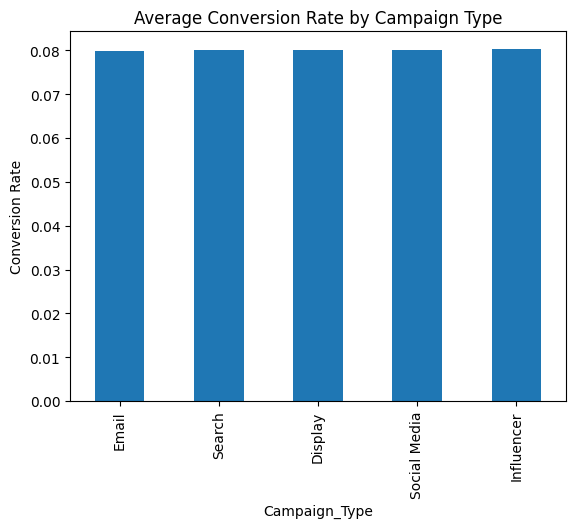

In [27]:
import matplotlib.pyplot as plt

df.groupby("Campaign_Type")["Conversion_Rate"].mean().sort_values().plot(kind="bar")
plt.title("Average Conversion Rate by Campaign Type")
plt.ylabel("Conversion Rate")
plt.show()

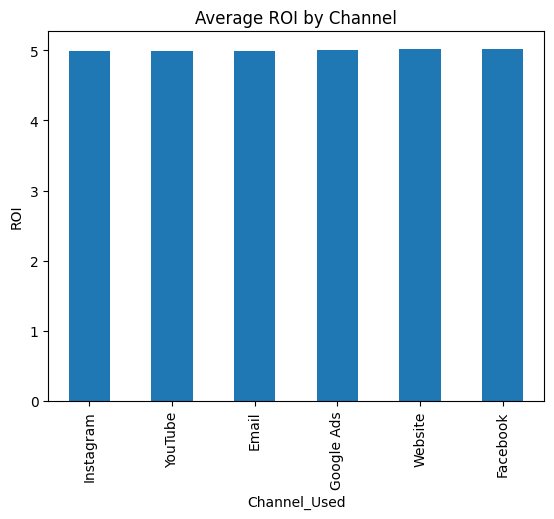

In [28]:
df.groupby("Channel_Used")["ROI"].mean().sort_values().plot(kind="bar")
plt.title("Average ROI by Channel")
plt.ylabel("ROI")
plt.show()

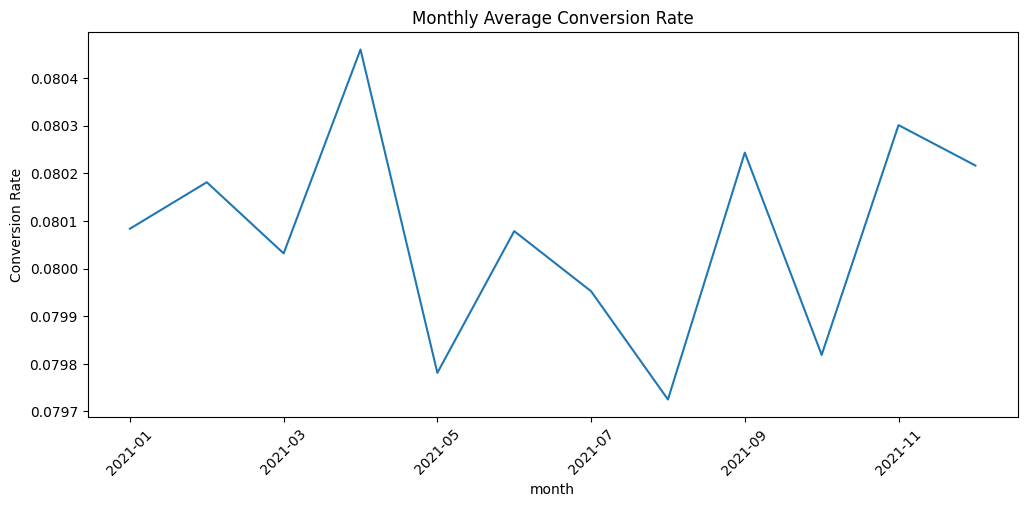

In [29]:
monthly = df.groupby("month")["Conversion_Rate"].mean()

monthly.plot(figsize=(12,5))
plt.title("Monthly Average Conversion Rate")
plt.xticks(rotation=45)
plt.ylabel("Conversion Rate")
plt.show()

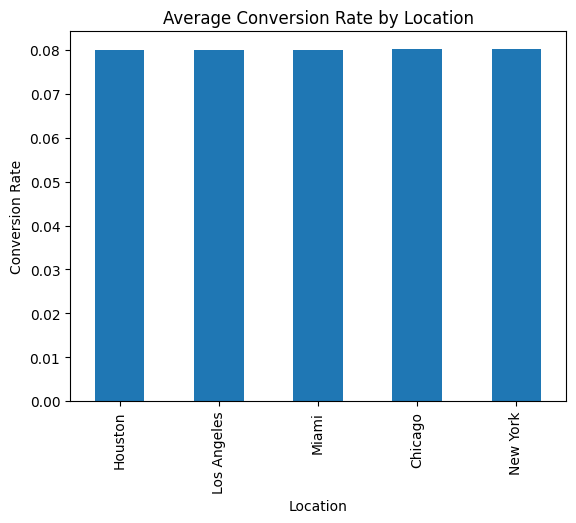

In [30]:
df.groupby("Location")["Conversion_Rate"].mean().sort_values().plot(kind="bar")
plt.title("Average Conversion Rate by Location")
plt.ylabel("Conversion Rate")
plt.show()

<Axes: >

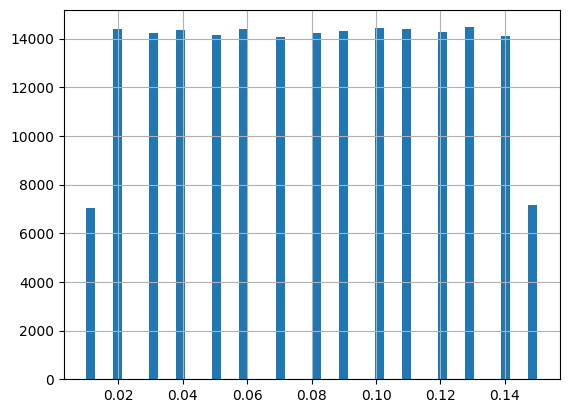

In [31]:
df["Conversion_Rate"].hist(bins=50)

In [32]:
avg_order_value = 50

df["Sales"] = df["Clicks"] * df["Conversion_Rate"] * avg_order_value

In [33]:
df[["Clicks", "Conversion_Rate", "Sales"]].head()

,Clicks,Conversion_Rate,Sales
0,506,0.04,1012.0
1,116,0.12,696.0
2,584,0.07,2044.0
3,217,0.11,1193.5
4,379,0.05,947.5


In [34]:
q_low, q_high = df["Sales"].quantile([0.01, 0.99])
df["Sales_clipped"] = df["Sales"].clip(q_low, q_high)

# log transform (əsas target)
import numpy as np
df["log_Sales"] = np.log1p(df["Sales_clipped"])

In [35]:
df["treated"] = (df["Campaign_Type"] == "Influencer").astype(int)

In [36]:
cutoff = df["Date"].median()
df["post"] = (df["Date"] >= cutoff).astype(int)

In [37]:
df["post"].value_counts()

,count
post,
1,100264
0,99736


In [38]:
panel = df.groupby(["Location", "Date"]).agg(
    log_Sales=("log_Sales", "mean"),
    Clicks=("Clicks", "sum"),
    Impressions=("Impressions", "sum"),
    Engagement_Score=("Engagement_Score", "mean"),
    Acquisition_Cost=("Acquisition_Cost", "mean"),
    treated_share=("treated", "mean"),
    post=("post", "max")
).reset_index()

In [39]:
panel.head()

,Location,Date,log_Sales,Clicks,Impressions,Engagement_Score,Acquisition_Cost,treated_share,post
0,Chicago,2021-01-01,7.253241,58205,587440,5.611111,12645.490741,0.129630,0
1,Chicago,2021-01-02,7.319614,57531,580060,5.336538,12350.923077,0.173077,0
2,Chicago,2021-01-03,7.315423,61762,649929,5.590909,13267.245455,0.209091,0
3,Chicago,2021-01-04,7.187412,55445,545591,5.460784,11720.431373,0.205882,0
4,Chicago,2021-01-05,7.375008,68359,647248,5.252101,12604.075630,0.201681,0


In [40]:
panel.tail()

,Location,Date,log_Sales,Clicks,Impressions,Engagement_Score,Acquisition_Cost,treated_share,post
1820,New York,2021-12-27,7.413921,62218,622185,5.681416,12214.584071,0.168142,1
1821,New York,2021-12-28,7.437833,65639,674672,5.441667,12462.050000,0.175000,1
1822,New York,2021-12-29,7.287278,63039,576232,5.709091,12227.563636,0.181818,1
1823,New York,2021-12-30,7.418321,68302,664145,5.637097,11788.693548,0.153226,1
1824,New York,2021-12-31,7.337861,62634,645701,5.483051,12481.059322,0.203390,1


In [41]:
panel["treated_share"].describe()

,treated_share
count,1825.000000
mean,0.200845
std,0.038292
min,0.091603
25%,0.174312
50%,0.200000
75%,0.226190
max,0.327586


In [42]:
panel["treated"] = (panel["treated_share"] > 0.2).astype(int)

In [43]:
panel["post"].value_counts()

,count
post,
1,915
0,910


In [44]:
panel["treated"].value_counts()

,count
treated,
0,933
1,892


In [45]:
panel.groupby(["treated","post"]).size()

treated  post
0        0       473
         1       460
1        0       437
         1       455
dtype: int64

In [46]:
panel["did"] = panel["treated"] * panel["post"]

In [47]:
panel['did'].value_counts()

,count
did,
0,1370
1,455


In [48]:
panel["time_index"] = (panel["Date"] - panel["Date"].min()).dt.days

In [49]:
import matplotlib.pyplot as plt

plot_df = panel.groupby(["post", "treated"])["log_Sales"].mean().reset_index()
plot_df

,post,treated,log_Sales
0,0,0,7.372783
1,0,1,7.370313
2,1,0,7.369510
3,1,1,7.370712


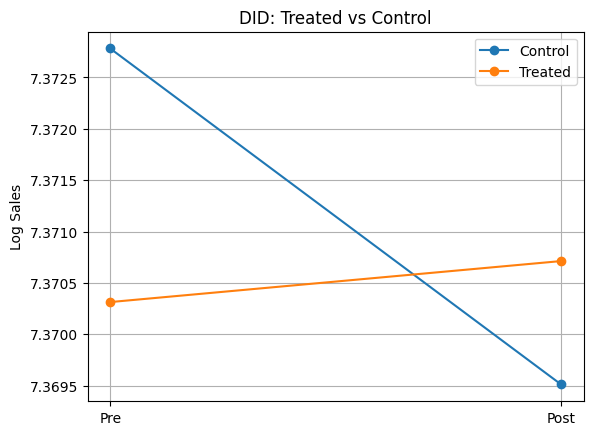

In [50]:
for t in plot_df["treated"].unique():
    subset = plot_df[plot_df["treated"] == t]
    label = "Treated" if t == 1 else "Control"
    plt.plot(subset["post"], subset["log_Sales"], marker='o', label=label)

plt.xticks([0,1], ["Pre","Post"])
plt.title("DID: Treated vs Control")
plt.ylabel("Log Sales")
plt.legend()
plt.grid()
plt.show()

In [51]:
import numpy as np

panel["log_Clicks"] = np.log1p(panel["Clicks"])
panel["log_Impressions"] = np.log1p(panel["Impressions"])
panel["log_Acquisition_Cost"] = np.log1p(panel["Acquisition_Cost"])

In [52]:
import statsmodels.formula.api as smf

model = smf.ols(
    """
    log_Sales ~ post + did
    + log_Clicks + log_Impressions + Engagement_Score + log_Acquisition_Cost
    + C(Location) + time_index
    """,
    data=panel
).fit(cov_type="HC3")

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_Sales   R-squared:                       0.234
Model:                            OLS   Adj. R-squared:                  0.230
Method:                 Least Squares   F-statistic:                     52.76
Date:                Wed, 13 May 2026   Prob (F-statistic):          3.21e-101
Time:                        20:47:59   Log-Likelihood:                 2176.2
No. Observations:                1825   AIC:                            -4328.
Df Residuals:                    1813   BIC:                            -4262.
Df Model:                          11                                         
Covariance Type:                  HC3                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [53]:
import numpy as np
import pandas as pd

from econml.dml import LinearDML
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [54]:
Y = df["log_Sales"]          # outcome
T = df["treated"]            # treatment: Influencer = 1

features = [
    "Clicks",
    "Impressions",
    "Engagement_Score",
    "Acquisition_Cost",
    "Location",
    "Campaign_Type",
    "Channel_Used"
]

X = df[features].copy()

In [55]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
categorical_cols = ["Location", "Channel_Used"]
numeric_cols = ["Clicks", "Impressions", "Engagement_Score", "Acquisition_Cost"]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

In [58]:
from econml.dml import LinearDML
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor


est = LinearDML(
    model_y=RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=5,
        random_state=42
    ),

    model_t=RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=5,
        random_state=42
    ),

    discrete_treatment=True,
    random_state=42
)

In [59]:
X_transformed = preprocess.fit_transform(X)

est.fit(Y, T, X=X_transformed)

/usr/local/lib/python3.12/dist-packages/econml/sklearn_extensions/linear_model.py:1815: UserWarning: Co-variance matrix is underdetermined. Inference will be invalid!
  warnings.warn("Co-variance matrix is underdetermined. Inference will be invalid!")


In [60]:
ate = est.ate(X_transformed)
ate_interval = est.ate_interval(X_transformed)

print("ATE:", ate)
print("ATE interval:", ate_interval)

ATE: 0.0064933139671457295
ATE interval: (np.float64(-0.0007943577581619749), np.float64(0.013780985692453432))


In [61]:
effect_percent = (np.exp(ate) - 1) * 100

print(f"Estimated Sales Impact: {effect_percent:.2f}%")

Estimated Sales Impact: 0.65%


In [62]:
effects = est.effect(X_transformed)

df["econml_effect"] = effects

df["econml_effect_percent"] = (np.exp(df["econml_effect"]) - 1) * 100

df[["econml_effect", "econml_effect_percent"]].describe()

,econml_effect,econml_effect_percent
count,200000.000000,200000.000000
mean,0.006493,0.656268
std,0.009788,0.986033
min,-0.025413,-2.509234
25%,-0.000428,-0.042798
50%,0.006187,0.620591
75%,0.013071,1.315670
max,0.041784,4.266961


In [63]:
df.groupby("Location")["econml_effect_percent"].mean()

,econml_effect_percent
Location,
Chicago,1.194639
Houston,0.271935
Los Angeles,0.769299
Miami,0.864132
New York,0.177838


In [64]:
df.groupby("Channel_Used")["econml_effect_percent"].mean()

,econml_effect_percent
Channel_Used,
Email,1.789900
Facebook,0.381799
Google Ads,0.803653
Instagram,0.589787
Website,-0.070907
YouTube,0.430739


In [65]:
did_table = df.groupby(["treated", "post"])["Sales"].mean().unstack()

print(did_table)

post               0            1
treated                          
0        2199.776166  2200.721864
1        2206.462186  2202.985421


In [66]:
print(df["post"].unique()) # Burada həm 0, həm 1 görünməlidir
print(df.shape)            # Sətirlərin sayı eynidirmi?

[0 1]
(200000, 27)


In [67]:
control_pre = did_table.loc[0, 0]
control_post = did_table.loc[0, 1]

treated_pre = did_table.loc[1, 0]
treated_post = did_table.loc[1, 1]
control_change = control_post - control_pre
treated_change = treated_post - treated_pre

In [68]:
did = treated_change - control_change

print("Treated change:", treated_change)
print("Control change:", control_change)
print("Raw DID:", did)

Treated change: -3.4767648432598435
Control change: 0.945697725903301
Raw DID: -4.4224625691631445


In [69]:
# Treated və control sales trend
ts = panel.groupby(["Date", "treated"])["log_Sales"].mean().unstack()

ts.columns = ["control", "treated"]
ts = ts.dropna()

In [70]:
ts

,control,treated
Date,,
2021-01-01,7.307948,7.310969
2021-01-03,7.345497,7.352168
2021-01-04,7.365397,7.302787
2021-01-05,7.454788,7.406224
2021-01-06,7.468263,7.428621
...,...,...
2021-12-27,7.367448,7.335105
2021-12-28,7.448774,7.396223
2021-12-29,7.344542,7.356045


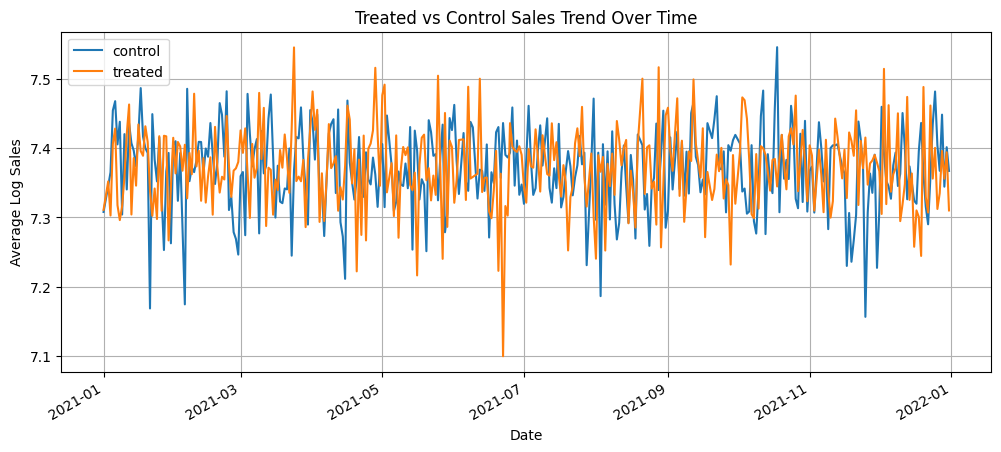

In [71]:
ts.plot(figsize=(12,5))
plt.title("Treated vs Control Sales Trend Over Time")
plt.ylabel("Average Log Sales")
plt.grid()
plt.show()

In [72]:
ate = est.ate(X_transformed)
ci = est.ate_interval(X_transformed)

print("ATE:", ate)
print("95% CI:", ci)
print("Effect %:", (np.exp(ate)-1)*100)

ATE: 0.0064933139671457295
95% CI: (np.float64(-0.0007943577581619749), np.float64(0.013780985692453432))
Effect %: 0.6514441234188206
